In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
words = open('names.txt', 'r').read().splitlines()

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [5]:
block_size = 3

def build_dataset(words):

    X, Y = [], []

    for w in words:

        context = [0] * block_size

        for ch in w + '.':
            ix = stoi[ch]

            X.append(context)
            Y.append(ix)

            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)

    return X, Y

In [6]:
import random
random.seed(42)
random.shuffle(words)

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [7]:
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((27,10), generator=g)

layers = [
    torch.randn((30,100), generator=g),
    torch.randn((100,100), generator=g),
    torch.randn((100,100), generator=g),
    torch.randn((100,100), generator=g),
    torch.randn((100,100), generator=g),
    torch.randn((100,27), generator=g)
]

In [8]:
parameters = [C] + layers

for p in parameters:
    p.requires_grad = True

In [9]:
emb = C[Xtr[:32]]
x = emb.view(-1,30)

for layer in layers[:-1]:
    x = torch.tanh(x @ layer)

logits = x @ layers[-1]

In [10]:
loss = F.cross_entropy(logits, Ytr[:32])
loss

tensor(23.8868, grad_fn=<NllLossBackward0>)

In [11]:
for p in parameters:
    p.grad = None

loss.backward()

(array([1.416e+03, 4.100e+01, 2.300e+01, 2.000e+01, 9.000e+00, 1.600e+01,
        2.000e+01, 9.000e+00, 1.200e+01, 5.000e+00, 7.000e+00, 5.000e+00,
        6.000e+00, 3.000e+00, 1.200e+01, 3.000e+00, 6.000e+00, 5.000e+00,
        8.000e+00, 4.000e+00, 6.000e+00, 1.500e+01, 1.000e+00, 1.000e+01,
        4.000e+00, 8.000e+00, 2.000e+00, 2.000e+00, 8.000e+00, 7.000e+00,
        1.000e+00, 9.000e+00, 3.000e+00, 6.000e+00, 5.000e+00, 1.200e+01,
        3.000e+00, 5.000e+00, 6.000e+00, 3.000e+00, 5.000e+00, 7.000e+00,
        6.000e+00, 8.000e+00, 2.200e+01, 1.400e+01, 1.400e+01, 2.100e+01,
        5.300e+01, 1.304e+03]),
 array([-1.  , -0.96, -0.92, -0.88, -0.84, -0.8 , -0.76, -0.72, -0.68,
        -0.64, -0.6 , -0.56, -0.52, -0.48, -0.44, -0.4 , -0.36, -0.32,
        -0.28, -0.24, -0.2 , -0.16, -0.12, -0.08, -0.04,  0.  ,  0.04,
         0.08,  0.12,  0.16,  0.2 ,  0.24,  0.28,  0.32,  0.36,  0.4 ,
         0.44,  0.48,  0.52,  0.56,  0.6 ,  0.64,  0.68,  0.72,  0.76,
         0.8 ,  0.84,

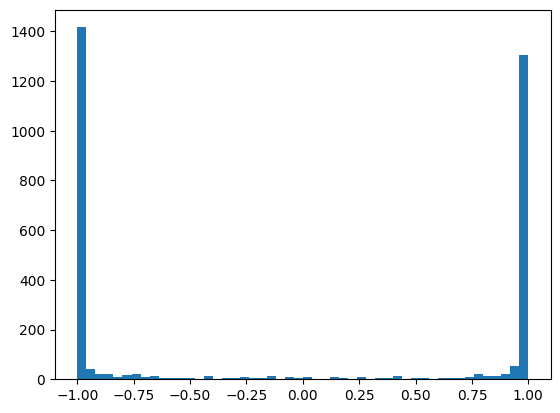

In [12]:
plt.hist(x.view(-1).tolist(), bins=50)

(array([  2.,   0.,   1.,   0.,   1.,   1.,   4.,   3.,   2.,   3.,   4.,
          5.,   5.,   4.,  14.,   9.,  16.,  21.,  34.,  33.,  64., 112.,
        224., 378., 624., 566., 329., 199., 108.,  77.,  41.,  37.,  16.,
         14.,   3.,  10.,   5.,   3.,   5.,   5.,   3.,   7.,   2.,   1.,
          1.,   0.,   1.,   1.,   1.,   1.]),
 array([-17.27254868, -16.57881069, -15.88507271, -15.19133472,
        -14.49759674, -13.80385876, -13.11012077, -12.41638279,
        -11.72264481, -11.02890682, -10.33516884,  -9.64143085,
         -8.94769287,  -8.25395489,  -7.5602169 ,  -6.86647892,
         -6.17274094,  -5.47900295,  -4.78526497,  -4.09152699,
         -3.397789  ,  -2.70405102,  -2.01031303,  -1.31657505,
         -0.62283707,   0.07090092,   0.7646389 ,   1.45837688,
          2.15211487,   2.84585285,   3.53959084,   4.23332882,
          4.9270668 ,   5.62080479,   6.31454277,   7.00828075,
          7.70201874,   8.39575672,   9.08949471,   9.78323269,
         10.476970

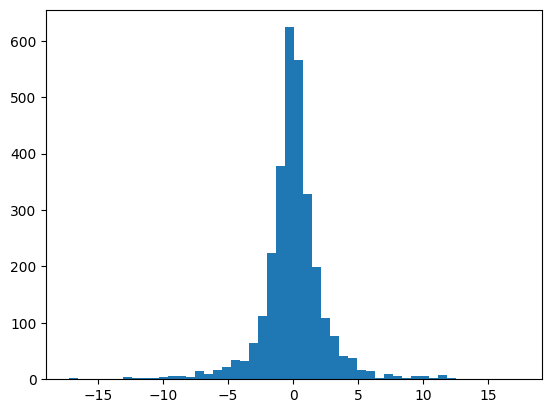

In [13]:
plt.hist(layers[0].grad.view(-1).tolist(), bins=50)

In [14]:
for i, layer in enumerate(layers):
    print(i, layer.grad.std().item())

0 2.578306198120117
1 0.7669485807418823
2 0.3420688807964325
3 0.12925635278224945
4 0.06316444277763367
5 0.05248742923140526
